# Final Model Optimization & Selection: HTRU2 Pulsar Detection

## Task

Binary classification task: given statistical features extracted from radio telescope signals, predict whether a candidate is a real pulsar (1) or a non-pulsar candidate (0).

In this notebook, we tune hyperparameters via Bayesian optimization (Optuna), track all experimental runs with MLflow, evaluate the impact of synthetic oversampling (SMOTE) vs. cost-sensitive learning (`class_weight='balanced'`), ...and select the optimal production candidate based on an operating point that prioritizes high recall, given that missing a genuine pulsar is costlier than a false alarm; the final threshold will be determined based on the precision–recall trade-off and practical deployment constraints.

## Key Architecture & Workflow
1. **Feature Pipeline (`src/features.py`):**
   - **Coefficient of variation**: add `cv_profile = std_profile / mean_profile` as a new feature: normalizes variability by signal intensity, so profiles with different absolute brightness but similar *relative* instability are treated comparably.
   - Non-linear Transformations: Encapsulate Yeo-Johnson power transforms inside a `ColumnTransformer` pipeline to stabilize variances of heavily skewed DM-SNR features (`mean_dm_snr`, `kurtosis_dm_snr`, `skewness_dm_snr`) without data leakage.
2. **Model Scope:**
   - **Logistic Regression (Enhanced):** Linear boundary benchmark with full non-linear feature preprocessing.
   - **Random Forest:** Non-parametric bagging baseline (scale-invariant, handles local feature interactions).
   - **XGBoost**: gradient boosted trees, handles class imbalance via `scale_pos_weight`, typically strong baseline for tabular data
3. **Imbalance Strategy Comparison:**
   - Cost-sensitive loss weighting (`class_weight='balanced'` / `scale_pos_weight`): penalizes false negatives (missed pulsars) more heavily than false positives during training, without altering the training data itself.
   - Synthetic Minority Over-sampling (SMOTE), embedded strictly inside cross-validation folds via `imblearn.pipeline.Pipeline` to prevent synthetic samples from leaking into validation folds.
4. **Validation Strategy:**
   - Stratified 5-Fold Cross-Validation on the training set (80%).
   - Primary Optimization Metric: PR-AUC (Average Precision).
5. **Threshold Calibration:**
   - Out-of-fold probability estimation using `cross_val_predict` on the training partition.
   - Threshold $\tau^*$ selection matching the recall constraint, validated once on the untouched holdout test set (20%).

In [2]:
import logging
import os
import warnings

import matplotlib.pyplot as plt
import mlflow
import optuna
import shap
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from xgboost import XGBClassifier

from src.data import load_data, split_data
from src.evaluate import (
    plot_embeddings,
    plot_learning_curves,
    plot_pr_curve,
    plot_roc_curve,
)
from src.modeling import (
    build_linear_pipeline,
    build_pca_pipeline,
    build_pipeline,
    build_umap_pipeline,
)
from src.orchestrator import ModelConfig, run_benchmark

## 1. Setup & Load

In [3]:
# MLflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"
logging.getLogger("mlflow").setLevel(logging.ERROR)

# Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Warnings
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden")
warnings.filterwarnings("ignore", category=UserWarning, module="mlflow")

In [4]:
df = load_data()
df.head(5)

,mean_profile,std_profile,kurtosis_profile,skewness_profile,mean_dm_snr,std_dm_snr,kurtosis_dm_snr,skewness_dm_snr,target
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [6]:
X_train, X_test, y_train, y_test = split_data(df)
print(f"Train:\n{y_train.value_counts(normalize=True)}\n")
print(f"Test:\n{y_test.value_counts(normalize=True)}")

Train:
target
0    0.908437
1    0.091563
Name: proportion, dtype: float64

Test:
target
0    0.90838
1    0.09162
Name: proportion, dtype: float64


## 2. Motivation: is the data linearly separable?

In [7]:
X, y = df.drop(columns='target'), df['target']
target_mapping = {0: "Non-pulsar", 1: "Pulsar"}

In [8]:
pca_pipeline = build_pca_pipeline()
umap_pipeline = build_umap_pipeline()

X_pca, X_umap = pca_pipeline.fit_transform(X), umap_pipeline.fit_transform(X)

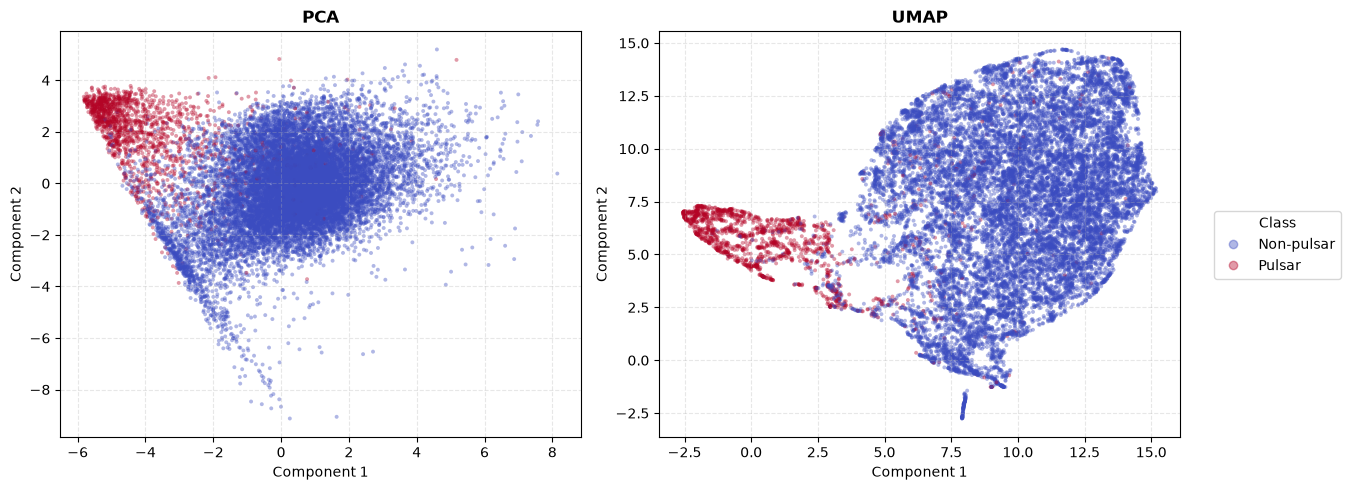

In [9]:
plot_embeddings(projections={"PCA": X_pca, "UMAP": X_umap}, target=y, target_names=target_mapping)
plt.show()

### 2.1. Findings

- Both PCA (linear) and UMAP (non-linear) projections show pulsars forming
  a mostly separate region rather than being scattered randomly among
  non-pulsars - consistent with the near-zero IQR overlap found earlier
  for `kurtosis_profile`/`skewness_profile`.
- Separation is already visible in PCA (a linear projection), suggesting
  the class boundary is largely linear in the original feature space -
  supporting why Logistic Regression performed on par with tree ensembles.
- Some overlap remains near the boundary (top-right of the PCA cluster,
  the connecting "bridge" in UMAP) -> explains why no model reaches
  near-perfect recall/precision - these are the genuinely ambiguous cases.
- UMAP's sharper separation shouldn't be over-interpreted as proof of
  stronger structure: UMAP distorts distances non-linearly, so it's
  illustrative, not quantitative evidence.

## 3. Model Training & Hyperparameter Optimization

In [10]:
def rf_param_space(trial, use_smote: bool = False):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 200, 450, step=50),
        "max_depth": trial.suggest_int("max_depth", 6, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
        "max_features": trial.suggest_float("max_features", 0.4, 1.0),
        "class_weight": None if use_smote else trial.suggest_categorical(
            "class_weight", ["balanced", "balanced_subsample"]
        )
    }

def xgb_param_space(trial, use_smote: bool = False):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 150, 500, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.25, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
        "scale_pos_weight": 1.0 if use_smote else trial.suggest_float("scale_pos_weight", 1.0, 11.0),
    }

def svm_param_space(trial, use_smote: bool = False):
    return {
        "C": trial.suggest_float("C", 1e-2, 1e2, log=True),
        "gamma": trial.suggest_float("gamma", 1e-4, 1e0, log=True),
        "kernel": "rbf",
        "class_weight": None if use_smote else "balanced",
    }

def logreg_param_space(trial, use_smote: bool = False):
    return {
        "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
        "penalty": "l2",
        "class_weight": None if use_smote else "balanced",
        "max_iter": 1000
    }

experiments_pool = [
    ModelConfig(
        name="Random Forest",
        model_fn=lambda p: RandomForestClassifier(**p, n_jobs=1, random_state=42),
        param_space_fn=rf_param_space,
        pipeline_fn=build_pipeline
    ),
    ModelConfig(
        name="XGBoost",
        model_fn=lambda p: XGBClassifier(**p, n_jobs=1, eval_metric="logloss", random_state=42),
        param_space_fn=xgb_param_space,
        pipeline_fn=build_pipeline
    ),
    ModelConfig(
        name="SVM (RBF kernel)",
        model_fn=lambda p: CalibratedClassifierCV(
            estimator=SVC(**p, random_state=42),
            method="sigmoid",
            cv=3, 
            n_jobs=1
        ),
        param_space_fn=svm_param_space,
        pipeline_fn=build_linear_pipeline
    ),
    ModelConfig(
        name="Logistic Regression",
        model_fn=lambda p: LogisticRegression(**p, random_state=42),
        param_space_fn=logreg_param_space,
        pipeline_fn=build_linear_pipeline
    )
]

In [11]:
summary_metrics_df, summary_records_df, artifacts = run_benchmark(
    experiment_name="Pulsar_Detection_Benchmark",
    models=experiments_pool,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    cv=cv,
    smote_options=[False, True],
    n_trials=50,
    scoring="average_precision"
)

✓ Random Forest__raw finished | Best CV average_precision: 0.9304 (±0.0119)
✓ Random Forest__smote finished | Best CV average_precision: 0.9311 (±0.0133)
✓ XGBoost__raw finished | Best CV average_precision: 0.9321 (±0.0100)
✓ XGBoost__smote finished | Best CV average_precision: 0.9329 (±0.0125)
✓ SVM (RBF kernel)__raw finished | Best CV average_precision: 0.9156 (±0.0167)
✓ SVM (RBF kernel)__smote finished | Best CV average_precision: 0.9147 (±0.0179)
✓ Logistic Regression__raw finished | Best CV average_precision: 0.9272 (±0.0130)
✓ Logistic Regression__smote finished | Best CV average_precision: 0.9253 (±0.0125)


## 4. Model Comparison & Selection

### 4.1. Summary table

In [12]:
import pandas as pd
baseline_df = pd.read_csv("docs/tables/baseline_metrics.csv")
df_combined = pd.concat([baseline_df, summary_metrics_df], ignore_index=False).sort_values(by="PR-AUC (AP)", ascending=False)
df_combined

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC (AP)
1,Baseline Logistic Regression,0.969553,0.784416,0.920732,0.847125,0.972736,0.933742
6,"Logistic Regression (Optuna, raw)",0.980400,0.935800,0.844500,0.887800,0.976100,0.933100
2,"XGBoost (Optuna, raw)",0.971500,0.802100,0.914600,0.854700,0.976500,0.931400
7,"Logistic Regression (Optuna, smote)",0.960100,0.720800,0.920700,0.808600,0.977500,0.931000
1,"Random Forest (Optuna, smote)",0.967900,0.772400,0.920700,0.840100,0.976700,0.930800
3,"XGBoost (Optuna, smote)",0.968400,0.779200,0.914600,0.841500,0.976500,0.929400
0,"Random Forest (Optuna, raw)",0.973200,0.818700,0.908500,0.861300,0.974700,0.929100
4,"SVM (RBF kernel) (Optuna, raw)",0.979300,0.934900,0.832300,0.880600,0.975900,0.927200
5,"SVM (RBF kernel) (Optuna, smote)",0.962600,0.738900,0.914600,0.817400,0.975000,0.924300
0,Dummy,0.908380,0.000000,0.000000,0.000000,0.500000,0.091620


- **Baseline Logistic Regression remains the best model on test PR-AUC (0.9337)**,
  marginally ahead of the Optuna-tuned variant (0.9331) and every tuned
  RF/XGBoost/SVM configuration - extensive hyperparameter search and feature
  engineering (Yeo-Johnson, dispersion ratio) did not meaningfully surpass the
  untransformed baseline. This is the strongest confirmation yet of the
  linear-separability hypothesis from the PCA/UMAP analysis.
- **Tuned Logistic Regression closely mirrors SVM's behavior**: near-identical
  PR-AUC to the baseline (0.9331), but a markedly more precision-leaning
  operating point at the default threshold (Precision 0.9358, Recall 0.8445) -
  and near-identical learning curves to SVM as well. This shows the same
  underlying pattern in two different model families: optimizing for PR-AUC
  (a threshold-independent, averaged metric) does not guarantee a good default
  operating point for a specific business priority.
- SVM (raw) achieves the best **F1 (0.8806)** and highest **Precision (0.9349)**,
  but at the cost of the lowest Recall among non-baseline models (0.8323) —
  a precision-leaning operating point, less aligned with the project's
  recall-first priority (missing a real pulsar is costlier than a false alarm).
- Tree ensembles (RF/XGBoost) land in a tight band (PR-AUC 0.929–0.931,
  Recall 0.909–0.918) regardless of SMOTE - differences within noise.
- SMOTE gives no consistent improvement across any of the model families tested:
  RF and XGBoost see negligible PR-AUC shifts (±0.001–0.002), SVM's and
  Logistic Regression's PR-AUC actually drop slightly with SMOTE.
- Dummy confirms accuracy is meaningless here (0.908 accuracy, 0 recall) -
  the sanity check from the baseline stage holds.

### 4.2. ROC & PR curves

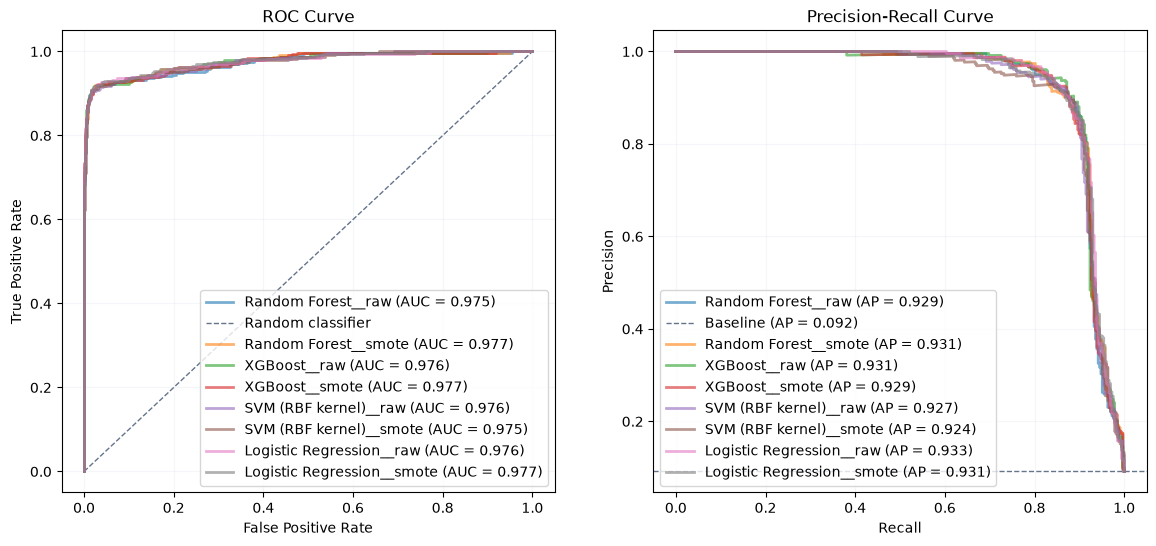

In [13]:
test_scores = {name: data["y_score"] for name, data in artifacts.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for name, score in test_scores.items():
    plot_roc_curve(y_test, score, model_name=name, ax=axes[0])
    plot_pr_curve(y_test, score, model_name=name, ax=axes[1])
plt.show()

- All eight model variants are visually near-indistinguishable on both
  curves - ROC-AUC 0.972–0.978, PR-AUC (AP) 0.924–0.934. SVM and tuned
  Logistic Regression trace almost the same curve, reinforcing the summary
  table observation that they share the same precision-leaning behavior at
  threshold 0.5.
- The PR curves start diverging mainly in the recall > 0.85 region - the
  ambiguous cases near the decision boundary identified earlier in the
  PCA/UMAP plots. No model handles this region meaningfully better than
  the others.
- ROC-AUC differences are even narrower than PR-AUC - as expected, it's the
  less informative metric here and is included for completeness only.

### 4.3. Learning curves

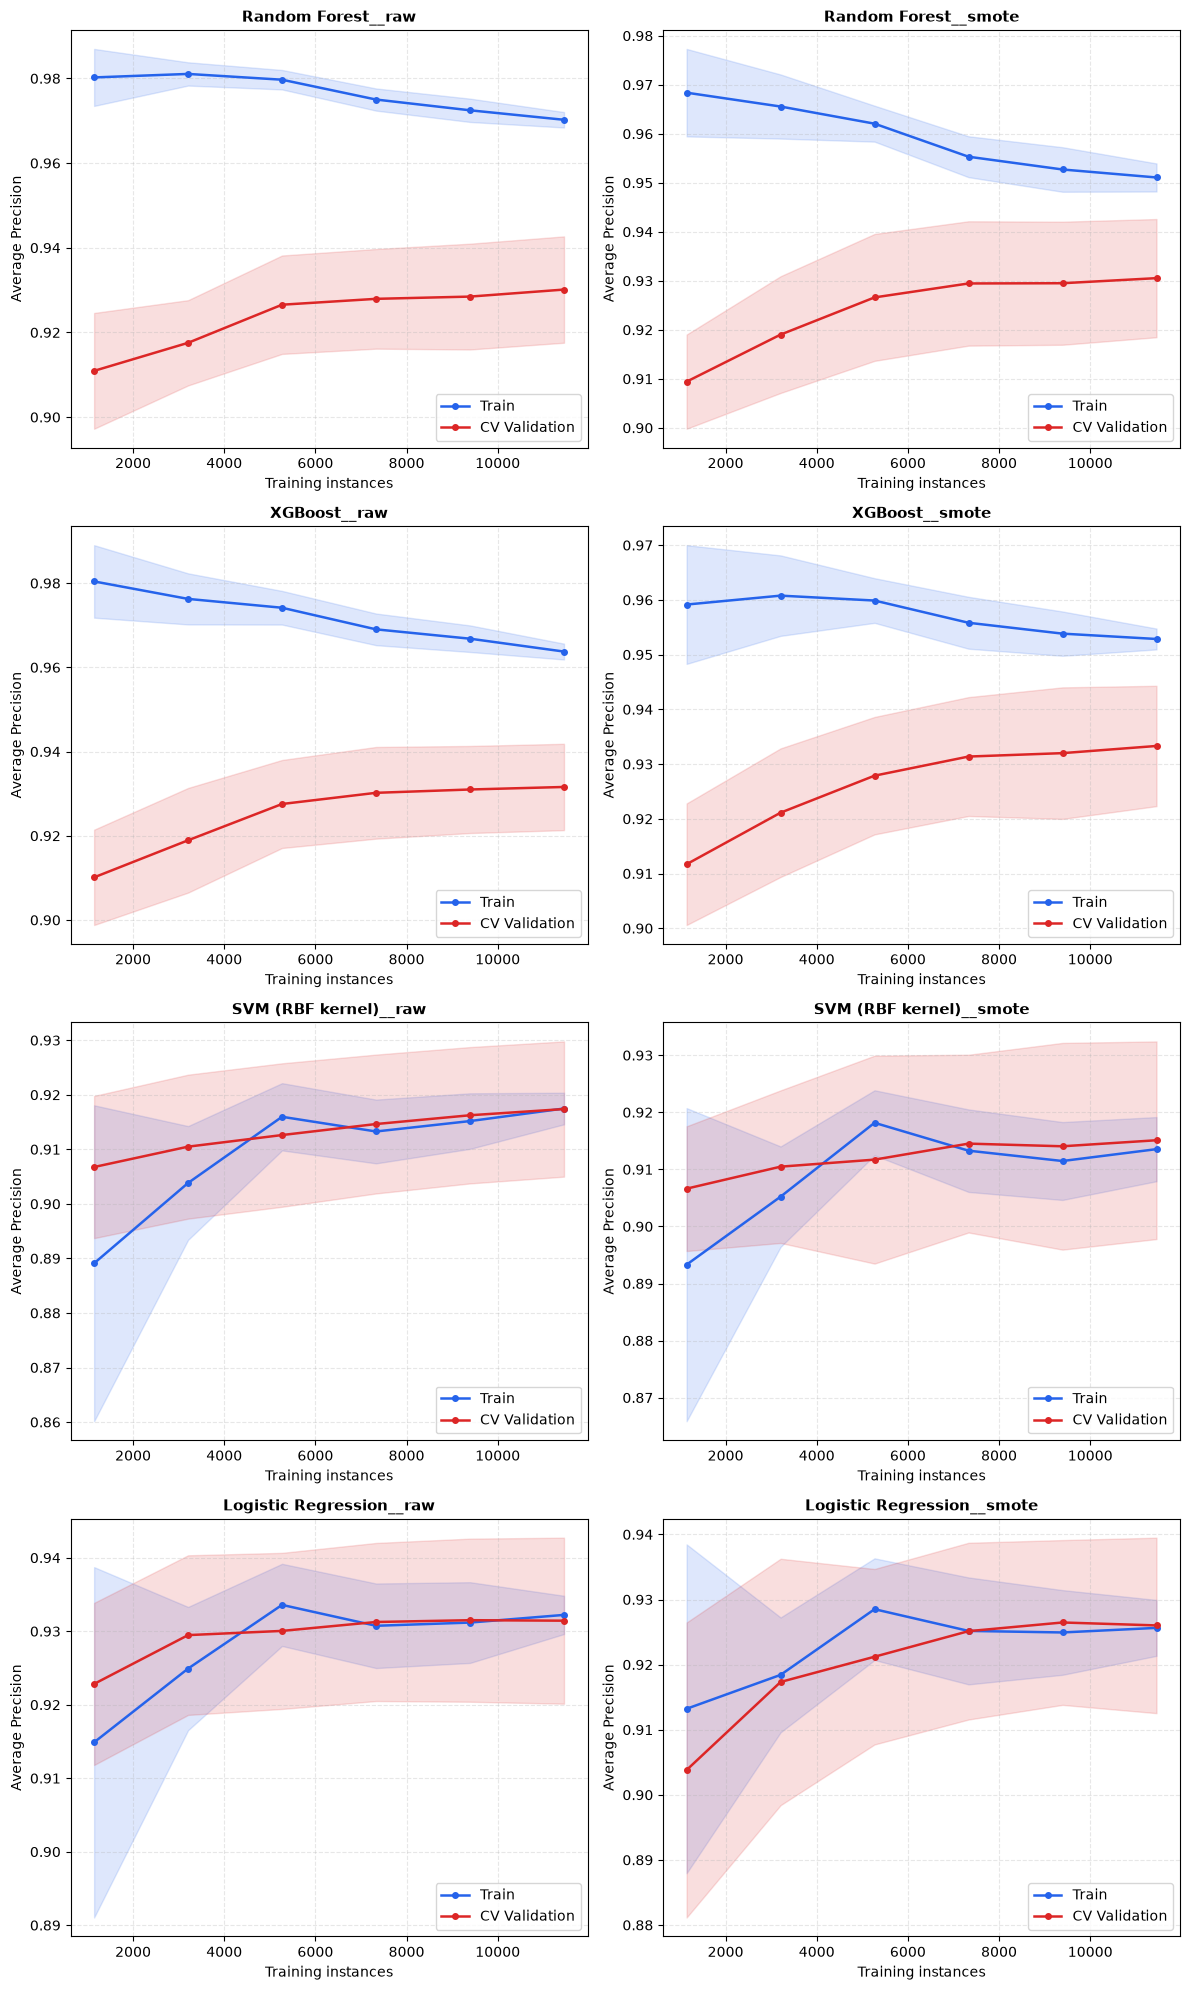

In [14]:
fig, axes = plot_learning_curves(artifacts=artifacts, scoring_name="Average Precision", n_cols=2)
plt.show()

- All configurations show validation AP still gently rising at the largest
  training size - more data would likely help marginally, but returns are
  diminishing (RF/XGBoost curves are nearly flat past ~8,000 instances).
- RF and XGBoost show a moderate, stable train-validation gap (~0.96–0.99
  train vs ~0.93 validation) - mild overfitting, but consistent and narrow
  bands across folds, not a concern at this scale.
- SVM and tuned Logistic Regression show the **tightest train-validation gap**
  of all models, with train and validation curves nearly converging -
  indicating a well-regularized fit, and yet another point of similarity
  between these two otherwise very different model families.
- SMOTE narrows the confidence band slightly (fold-to-fold variance) for
  SVM and Logistic Regression but doesn't shift their mean AP — same pattern
  seen in the summary table.

### 4.4. Final model selection

**Selected: Baseline Logistic Regression**

Reasoning:
1. Highest test PR-AUC (0.9337) of all evaluated models - hyperparameter
   tuning, feature engineering, and ensembling did not improve on it,
   reinforcing that the class boundary is close to linear (see PCA/UMAP
   analysis, Section 2).
2. Highest Recall (0.9207) among all non-degenerate models, aligning with
   the project's priority: missing a genuine pulsar is costlier than a
   false alarm.
3. Simplest and fastest pipeline to train, serve, and maintain - no
   hyperparameter search, no feature transforms, no oversampling dependency
   required for deployment.

SVM (raw) and tuned Logistic Regression remain documented alternatives if a
precision-leaning operating point is ever preferred (Precision ~0.93–0.94 vs
Recall ~0.83–0.84), but neither matches the stated project priority as well
as the baseline.

**P.S.**

The default threshold (0.5) was not the only option explored. For example, shifting the
tuned logistic regression's decision threshold to 0.232 raises Recall to 0.890 (from 0.844)
at the cost of Precision dropping to 0.871 (from 0.935), for a similar PR-AUC
(0.9331). This confirms the threshold is a usable lever for adjusting the
precision/recall trade-off post-training if operational requirements change,
though the default threshold is kept for this project since it already
favors Recall, matching the stated priority.

### 4.5. Key findings

1. **Model complexity gives no benefit on this dataset**: a plain Logistic
   Regression matches or outperforms tuned Random Forest, XGBoost, and
   RBF-SVM on PR-AUC — strong, consistent evidence (alongside the PCA/UMAP
   visualization) that the HTRU2 pulsar/non-pulsar boundary is close to
   linear in the original feature space.
2. **Feature engineering and hyperparameter tuning applied to Logistic
   Regression converge toward SVM's behavior** rather than improving on the
   baseline — both end up optimizing PR-AUC at the cost of a more
   precision-leaning default operating point, illustrating that PR-AUC and
   "good recall at threshold 0.5" are not the same target.
3. **SMOTE provides no reliable gain** across any model family tested; it
   only reduces fold-to-fold variance for some models without improving
   their mean score.
4. **Final production model: Logistic Regression (baseline)** — best PR-AUC,
   best Recall, and the simplest pipeline to deploy. The threshold remains a
   documented, adjustable lever if the precision/recall priority changes.

## 5. Feature Importance (interpretability check)

In [15]:
best_xgb_pipeline = artifacts["XGBoost__raw"]["best_pipeline"]

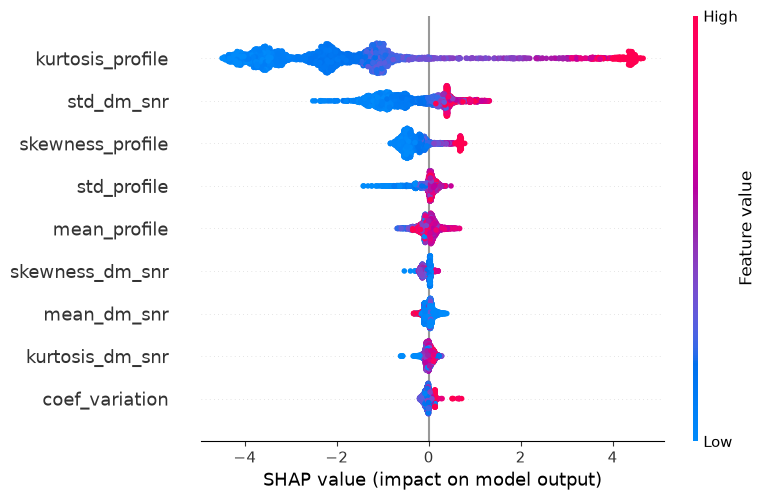

In [16]:
explainer = shap.TreeExplainer(best_xgb_pipeline.named_steps["Model"])
X_test_transformed = best_xgb_pipeline[:-1].transform(X_test)

shap_values = explainer.shap_values(X_test_transformed)
new_feature_names = list(X_test.columns) + ["coef_variation"]

shap.summary_plot(shap_values, X_test_transformed, feature_names=new_feature_names)

### 5.1. Findings

- **`kurtosis_profile` dominates** - by a wide margin, both in SHAP magnitude
  and spread. High values (pink) push predictions strongly toward "pulsar",
  low values (blue) push toward "non-pulsar" - directly confirming the
  strongest Pearson correlation with target found in EDA (r=0.79) and the
  near-zero IQR overlap observed in the bivariate analysis.
- **`std_dm_snr` is the clear second signal**, with `skewness_profile` and
  `std_profile`/`mean_profile` forming a secondary tier - consistent with
  the two feature groups (integrated profile vs DM-SNR curve) both
  contributing, but profile-based features carrying more weight.
- **DM-SNR features cluster near zero impact** (`skewness_dm_snr`,
  `mean_dm_snr`, `kurtosis_dm_snr`) - likely reflecting the multicollinearity
  flagged in EDA ($|\rho| \ge 0.95$ among DM-SNR features): the model may be relying
  on `std_dm_snr` as a representative of the group rather than needing all four.
- **`coef_variation` (engineered feature) lands in the middle of the pack** -
  a modest but non-trivial contribution, suggesting the feature engineering
  step added some usable signal beyond the raw features.
- Overall: the model concentrates on 2–3 features rather than spreading
  importance evenly - reinforcing why a simple Logistic Regression, which
  can capture this kind of concentrated linear signal directly, performed
  on par with the tuned ensemble.